# Contribution Figures (A/B/C)

Notebook ini menghasilkan **Fig. A1–A3, B1–B3, C1** sesuai daftar kontribusi.
Semua gambar disimpan ke `results/figures/` dalam format **PDF + PNG**.
Notebook ini **menjalankan semua dataset** yang tersedia di `DATASETS`.



**Cell ini (konfigurasi & helper)**

- Mengatur daftar dataset dan cache representatif untuk plot slot‑level.
- Mendefinisikan fungsi pembaca summary JSON dan slot‑log JSONL.
- Mengatur style plotting agar konsisten dengan publikasi ilmiah (serif, grid halus, warna stabil).



In [2]:
from __future__ import annotations
import json, math, re, statistics
from pathlib import Path
import matplotlib.pyplot as plt

RESULTS_ROOT = Path('results')
OUT_DIR = Path('results/figures')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Run for all datasets
DATASETS = ['wiki2018', 'wikipedia_september_2007']
CACHE_FOR_TIMESERIES = {
    'wiki2018': 40308,              # wiki2018: 40308 / 60463
    'wikipedia_september_2007': 30554,  # sep2007: 30554 / 45831
}

# Methods for Fig A1 (include GDBT A2)
M_A1 = ['baseline_lru', 'ilnse_A2_fixed', 'ilnse_A2_drift_only', 'ilnse_A2_full', 'gdbt_A2']
M_A1_LABELS = {
    'baseline_lru': 'LRU',
    'ilnse_A2_fixed': 'IL-backbone (Fixed M)',
    'ilnse_A2_drift_only': 'Drift-only',
    'ilnse_A2_full': 'Ours (Full)',
    'gdbt_A2': 'GDBT (A2)',
}

M_ABL = ['ilnse_A2_fixed','ilnse_A2_drift_only','ilnse_A2_guard_only','ilnse_A2_full']

STYLE = {
    'baseline_lru': dict(color='#7F7F7F', lw=1.8, ls='--'),
    'ilnse_A2_fixed': dict(color='#9467bd', lw=2.0, ls='--'),
    'ilnse_A2_drift_only': dict(color='#ff7f0e', lw=2.0, ls='-.'),
    'ilnse_A2_guard_only': dict(color='#2ca02c', lw=2.0, ls='-'),
    'ilnse_A2_full': dict(color='#d62728', lw=2.5, ls='-'),
    'gdbt_A2': dict(color='#1f77b4', lw=2.0, ls=':'),
}

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'lines.linewidth': 2.0,
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.linewidth': 0.6,
    'grid.alpha': 0.6,
})

def save_fig(fig, path: Path):
    fig.tight_layout()
    fig.savefig(path, bbox_inches='tight')
    fig.savefig(path.with_suffix('.png'), dpi=300, bbox_inches='tight')


def load_latest_summaries(dataset_dir: Path):
    pat = re.compile(r'^(\d{3})_summary_(.+)_(\d+)\.json$')
    records = {}
    for p in dataset_dir.glob('*_summary_*.json'):
        if p.name.endswith('_all_sizes.json'):
            continue
        m = pat.match(p.name)
        if not m:
            continue
        run_id = int(m.group(1))
        model = m.group(2)
        cache = int(m.group(3))
        key = (model, cache)
        cur = records.get(key)
        if cur is None or run_id > cur[0]:
            records[key] = (run_id, json.loads(p.read_text()))
    return {k: v[1] for k,v in records.items()}


def iter_jsonl(path: Path):
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            yield json.loads(line)


def get_caches(records):
    return sorted({c for (_,c) in records})


def compute_raw_budget(row, capacity_objects):
    miss_requests = row.get('miss_requests', 0)
    if miss_requests <= 0:
        return 0
    alpha = row.get('admission_alpha', 0.0)
    pressure = row.get('pressure_mult', 1.0)
    return int(math.ceil(capacity_objects * alpha * pressure))


def compute_pre_gate_budget(row, capacity_objects):
    raw = compute_raw_budget(row, capacity_objects)
    miss_candidates = row.get('miss_candidates', 0)
    fill_phase = bool(row.get('fill_phase'))
    fill_min_budget = row.get('fill_min_budget', 0)
    if fill_phase and raw < fill_min_budget:
        raw = fill_min_budget
    if miss_candidates <= 0:
        return 0
    if raw > miss_candidates:
        raw = miss_candidates
    return raw



**Cell ini (sanity check data)**

- Menampilkan dataset aktif, jumlah summary yang terbaca, daftar model, dan ukuran cache yang tersedia.
- Pastikan output menunjukkan model dan cache yang Anda butuhkan sebelum lanjut ke plotting.



In [3]:
for dataset in DATASETS:
    dataset_dir = RESULTS_ROOT / dataset
    records = load_latest_summaries(dataset_dir)
    print('DATASET:', dataset, 'dir:', dataset_dir)
    print('loaded summaries:', len(records))
    print('models:', sorted({m for (m,_) in records}))
    print('caches:', get_caches(records))



DATASET: wiki2018 dir: results/wiki2018
loaded summaries: 90
models: ['ilnse_A1_full', 'ilnse_A2_drift_only', 'ilnse_A2_fixed', 'ilnse_A2_full', 'ilnse_A2_guard_no_gate', 'ilnse_A2_guard_no_guard', 'ilnse_A2_guard_no_quality', 'ilnse_A2_guard_only', 'ilnse_A2_guard_precision_only', 'ilnse_A2_guard_qsweep_q0.9_ema0.1_min0.7_max1.3_boost0.1_gate0.05', 'ilnse_A2_guard_qsweep_q0.9_ema0.2_min0.5_max1.3_boost0.1_gate0.05', 'ilnse_A2_guard_qsweep_q0.9_ema0.2_min0.5_max1.5_boost0.1_gate0.05', 'ilnse_A2_guard_qsweep_q0.9_ema0.2_min0.7_max1.3_boost0.1_gate0.05', 'ilnse_A2_guard_qsweep_q0.9_ema0.3_min0.7_max1.3_boost0.1_gate0.05', 'ilnse_A2_guard_quality_only']
caches: [16123, 20154, 40308, 60463, 80617, 100772]
DATASET: wikipedia_september_2007 dir: results/wikipedia_september_2007
loaded summaries: 94
models: ['ilnse_A1_full', 'ilnse_A2_drift_only', 'ilnse_A2_fixed', 'ilnse_A2_full', 'ilnse_A2_full_dt', 'ilnse_A2_full_svm', 'ilnse_A2_guard_no_gate', 'ilnse_A2_guard_no_guard', 'ilnse_A2_guard_no

## Fig. A1 — HR vs Cache Size (all datasets)

**Tujuan:** membuktikan outcome utama (HR) di berbagai kapasitas cache.
**Data:** `hr_curve`/`hit_ratio` dari summary JSON per model.
**Output:** PDF+PNG kurva HR–C untuk LRU, IL‑fixed, Drift‑only, Full, dan GDBT(A2).



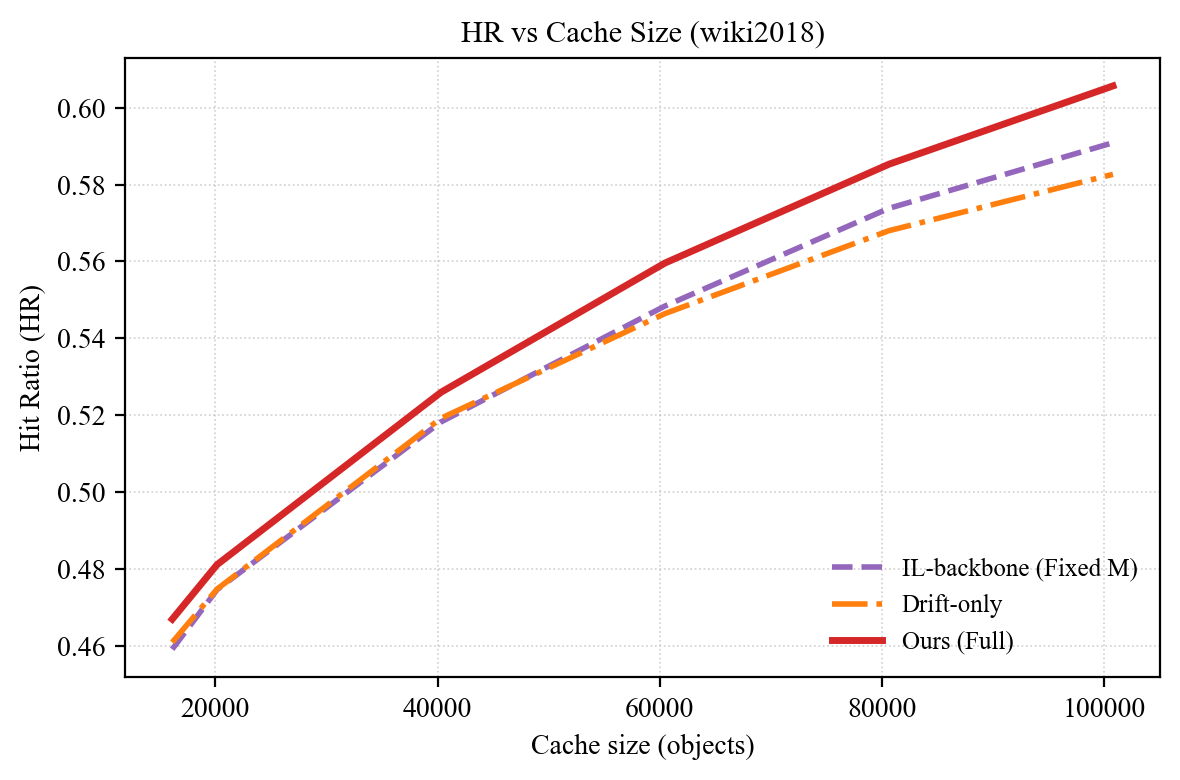

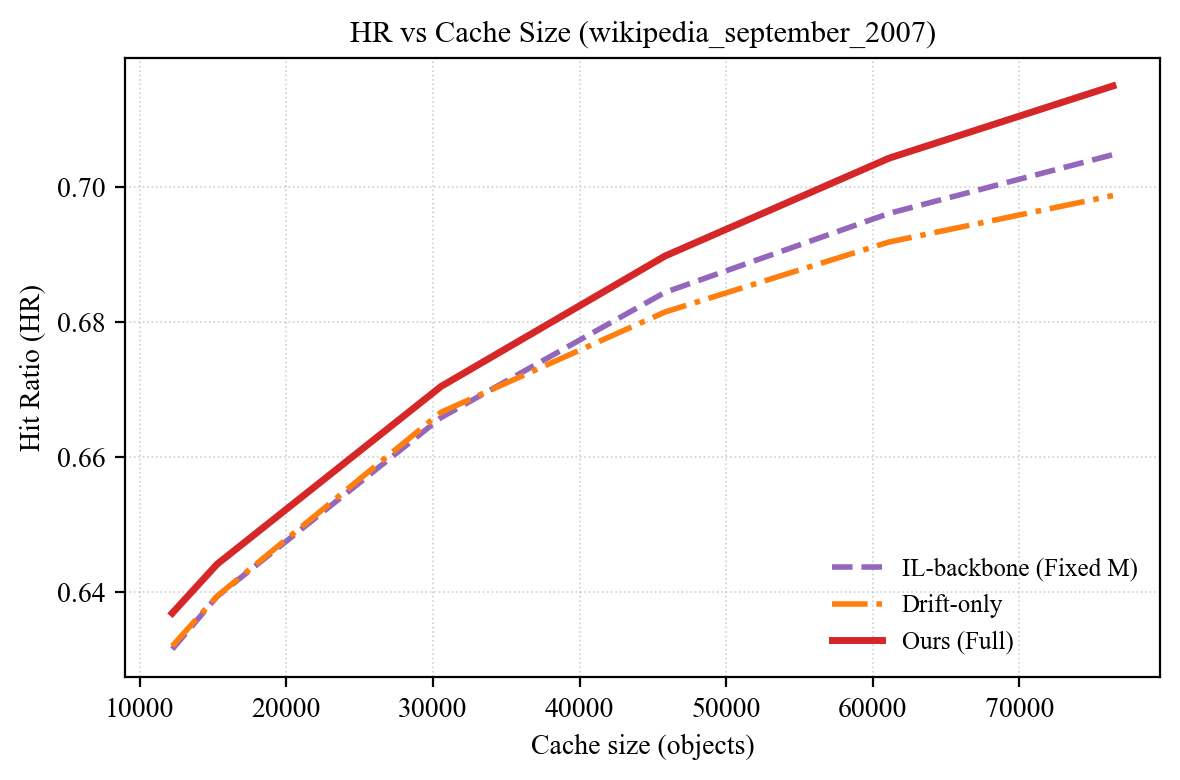

In [4]:
for dataset in DATASETS:
    dataset_dir = RESULTS_ROOT / dataset
    records = load_latest_summaries(dataset_dir)
    caches = get_caches(records)
    fig, ax = plt.subplots(figsize=(6.0, 4.0), dpi=200)
    for m in M_A1:
        pts = []
        for c in caches:
            val = records.get((m,c), {}).get('hit_ratio')
            if val is None:
                continue
            pts.append((c, val))
        if not pts:
            continue
        pts.sort(key=lambda x: x[0])
        xs = [p[0] for p in pts]; ys = [p[1] for p in pts]
        ax.plot(xs, ys, label=M_A1_LABELS.get(m, m), **STYLE.get(m, {}))
    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('Hit Ratio (HR)')
    ax.set_title(f'HR vs Cache Size ({dataset})')
    ax.legend(frameon=False, loc='lower right')
    ax.set_axisbelow(True)
    out = OUT_DIR / f'fig_A1_hr_{dataset}.pdf'
    save_fig(fig, out)



## Fig. A2 — Drift vs Budget vs Admitted (slot‑level, all datasets)

**Tujuan:** bukti mekanisme kontribusi 1 — drift memodulasi pressure (M_t).
**Data:** slot‑log JSONL (`slot_log_path`), fase `cache`.
**Output:** 3 panel time‑series: drift_norm, M_t, admitted rate.



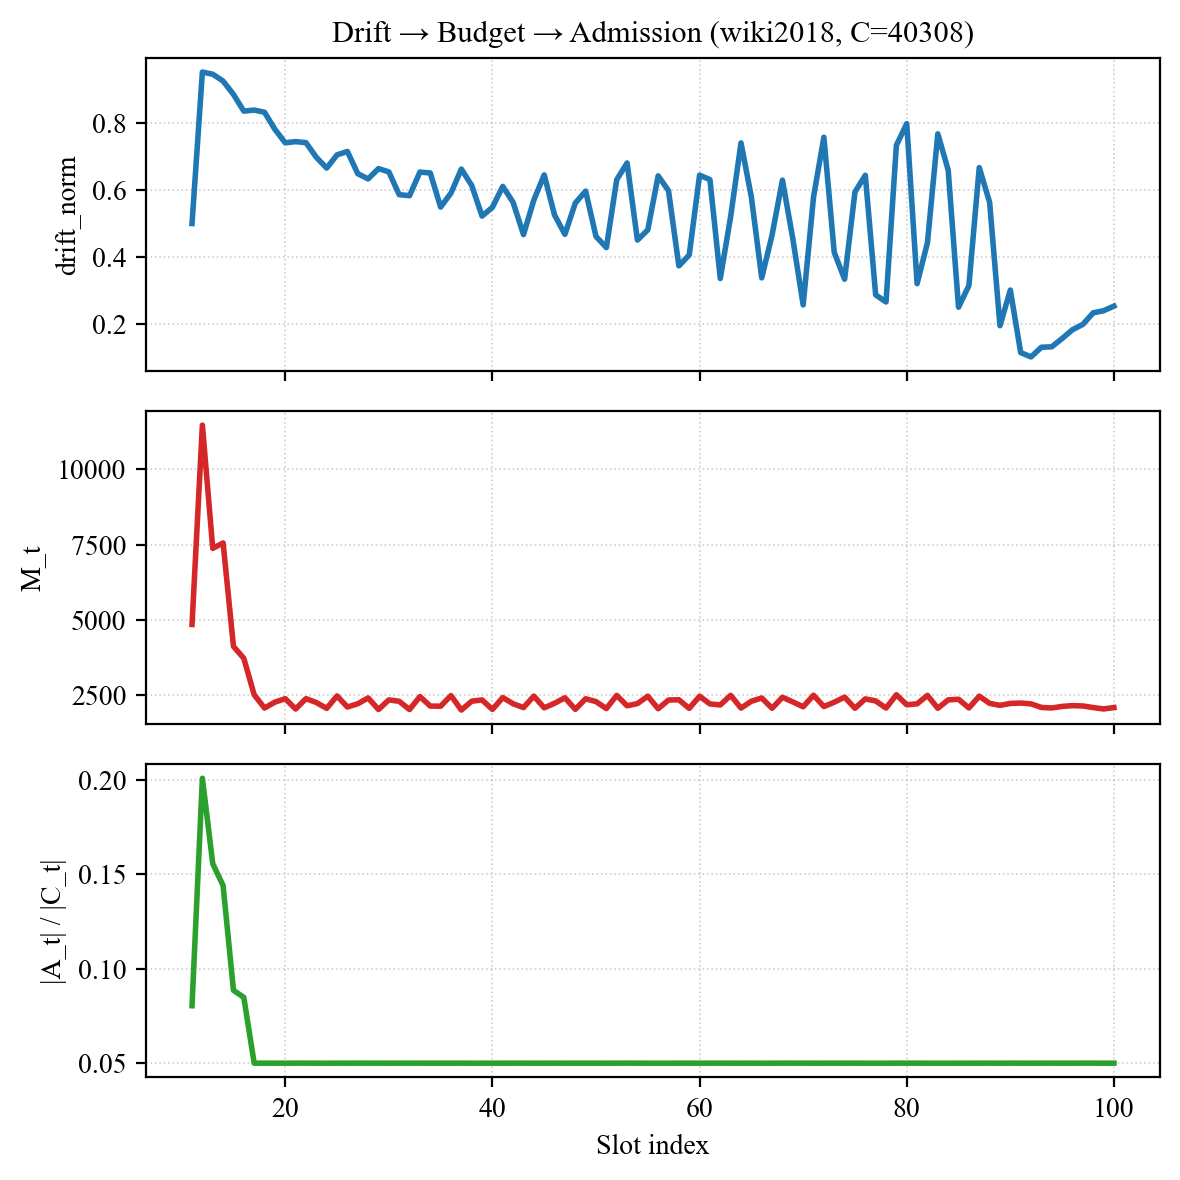

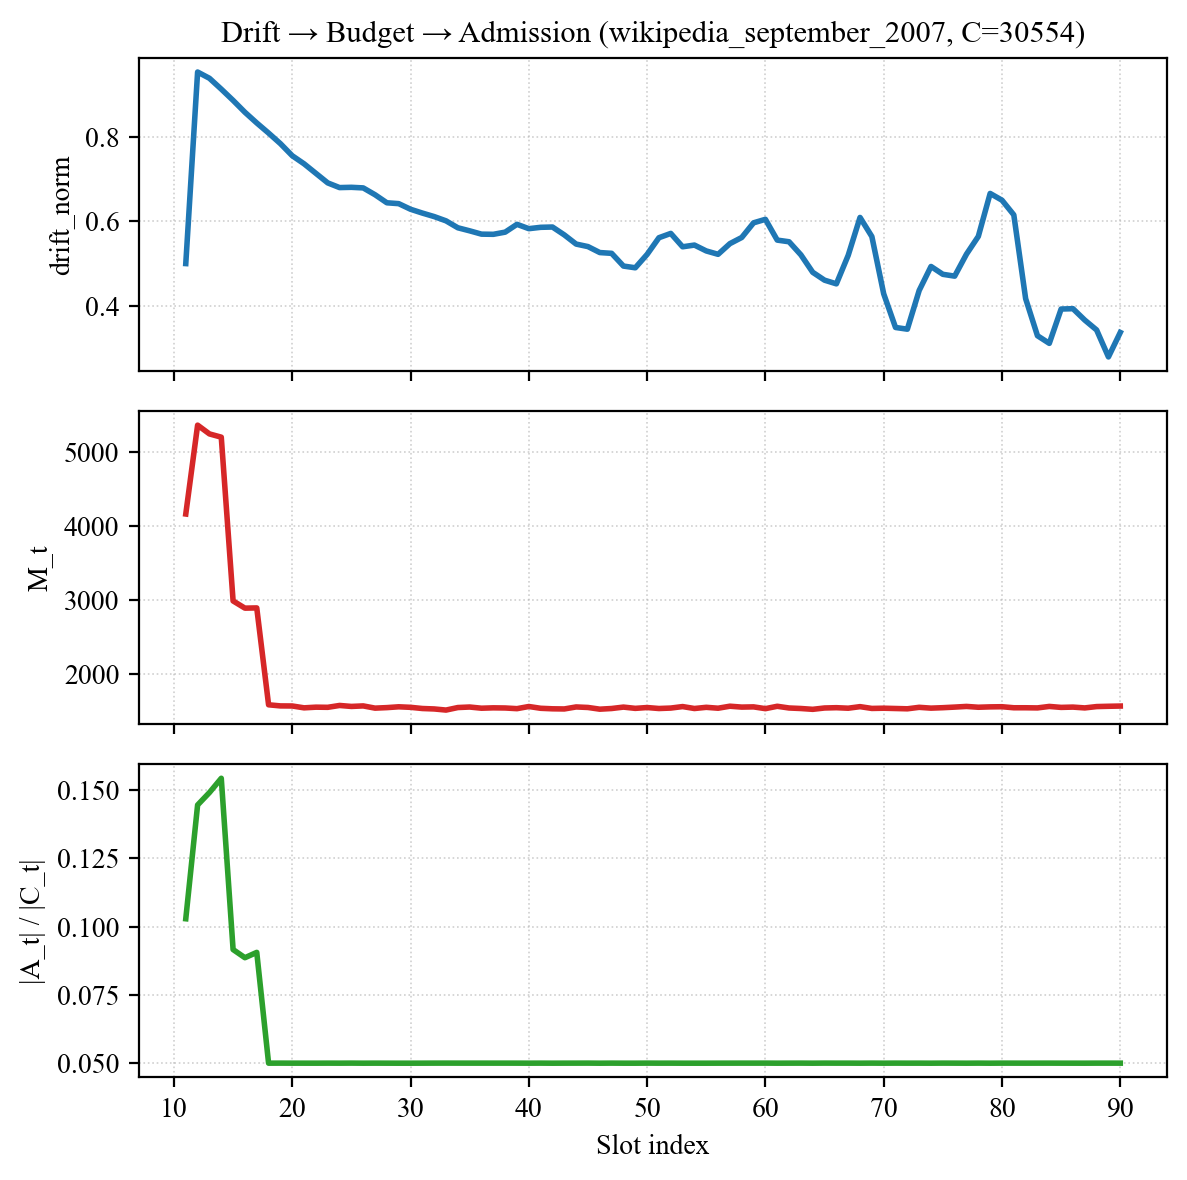

In [5]:
for dataset in DATASETS:
    dataset_dir = RESULTS_ROOT / dataset
    records = load_latest_summaries(dataset_dir)
    cache_ts = CACHE_FOR_TIMESERIES[dataset]
    s = records.get(('ilnse_A2_full', cache_ts))
    if not s or 'slot_log_path' not in s:
        raise ValueError(f'slot_log_path not found for A2_full at C={cache_ts} ({dataset})')
    slot_path = Path(s['slot_log_path'])

    slots, drift, budget, admit_rate = [], [], [], []
    for row in iter_jsonl(slot_path):
        if row.get('phase') != 'cache':
            continue
        slots.append(row.get('slot_index'))
        drift.append(row.get('drift_norm', row.get('drift_raw', 0.0)))
        budget.append(row.get('admit_budget', 0))
        mc = row.get('miss_candidates', 0)
        admit = row.get('admit_selected', 0)
        admit_rate.append((admit / mc) if mc else 0.0)

    fig, axs = plt.subplots(3, 1, figsize=(6.0, 6.0), dpi=200, sharex=True)
    axs[0].plot(slots, drift, color='#1f77b4')
    axs[0].set_ylabel('drift_norm')
    axs[1].plot(slots, budget, color='#d62728')
    axs[1].set_ylabel('M_t')
    axs[2].plot(slots, admit_rate, color='#2ca02c')
    axs[2].set_ylabel('|A_t| / |C_t|')
    axs[2].set_xlabel('Slot index')
    axs[0].set_title(f'Drift → Budget → Admission ({dataset}, C={cache_ts})')
    for ax in axs:
        ax.set_axisbelow(True)

    out = OUT_DIR / f'fig_A2_drift_budget_admit_{dataset}_{cache_ts}.pdf'
    save_fig(fig, out)



## Fig. A2b — Raw vs Final Budget (guardrail effect)

**Tujuan:** menunjukkan budget mentah hasil drift mapping vs budget final setelah guardrails.
**Data:** slot‑log JSONL (`admission_alpha`, `pressure_mult`, `miss_candidates`, `fill_min_budget`, `admit_budget`).
**Output:** time‑series raw budget, pre‑gate budget, dan final budget.



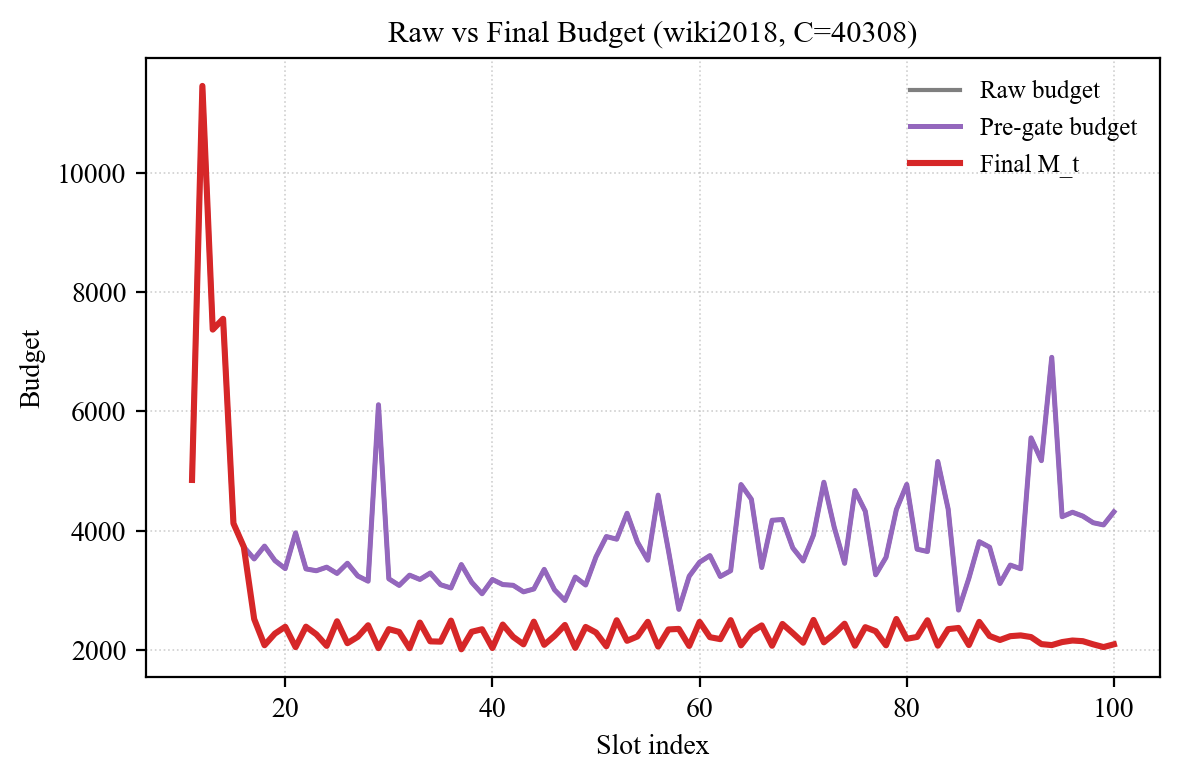

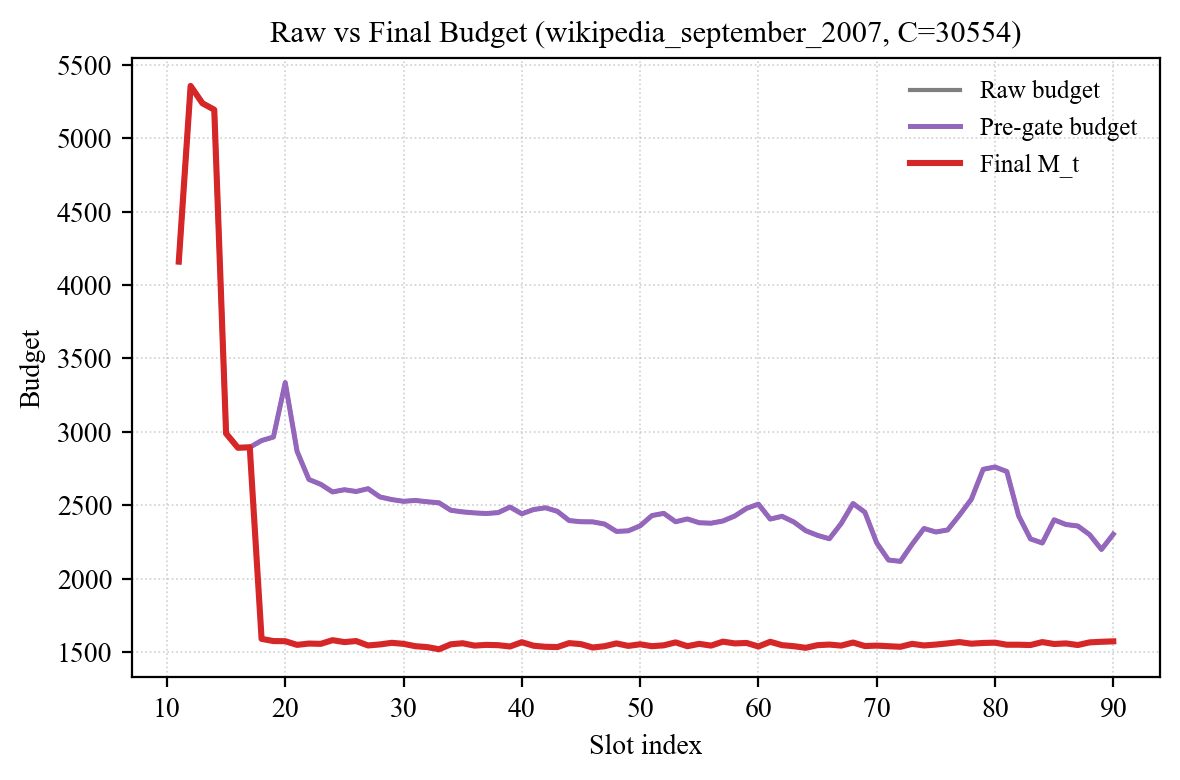

In [6]:
for dataset in DATASETS:
    dataset_dir = RESULTS_ROOT / dataset
    records = load_latest_summaries(dataset_dir)
    cache_ts = CACHE_FOR_TIMESERIES[dataset]
    s = records.get(('ilnse_A2_full', cache_ts))
    if not s or 'slot_log_path' not in s:
        raise ValueError(f'slot_log_path not found for A2_full at C={cache_ts} ({dataset})')
    slot_path = Path(s['slot_log_path'])
    capacity_objects = records.get(('ilnse_A2_full', cache_ts), {}).get('cache_size_objects', cache_ts)

    slots, raw_b, pre_b, final_b = [], [], [], []
    for row in iter_jsonl(slot_path):
        if row.get('phase') != 'cache':
            continue
        slots.append(row.get('slot_index'))
        raw = compute_raw_budget(row, capacity_objects)
        pre = compute_pre_gate_budget(row, capacity_objects)
        final = row.get('admit_budget', 0)
        raw_b.append(raw)
        pre_b.append(pre)
        final_b.append(final)

    fig, ax = plt.subplots(figsize=(6.0, 4.0), dpi=200)
    ax.plot(slots, raw_b, color='#7f7f7f', lw=1.5, label='Raw budget')
    ax.plot(slots, pre_b, color='#9467bd', lw=1.8, label='Pre-gate budget')
    ax.plot(slots, final_b, color='#d62728', lw=2.2, label='Final M_t')
    ax.set_xlabel('Slot index')
    ax.set_ylabel('Budget')
    ax.set_title(f'Raw vs Final Budget ({dataset}, C={cache_ts})')
    ax.legend(frameon=False, loc='upper right')
    ax.set_axisbelow(True)

    out = OUT_DIR / f'fig_A2b_raw_vs_final_{dataset}_{cache_ts}.pdf'
    save_fig(fig, out)



## Fig. A2c — Drift vs Budget Scatter (slot‑level)

**Tujuan:** memperlihatkan korelasi langsung drift_norm → M_t (bukan hanya binned).
**Data:** slot‑log JSONL (`drift_norm`, `admit_budget`).
**Output:** scatter drift_norm vs M_t.



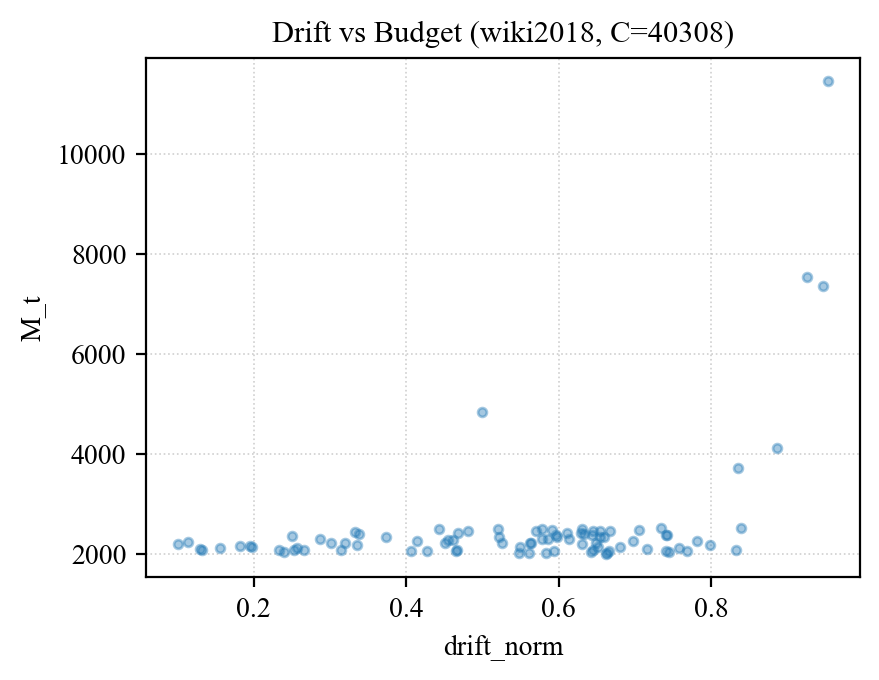

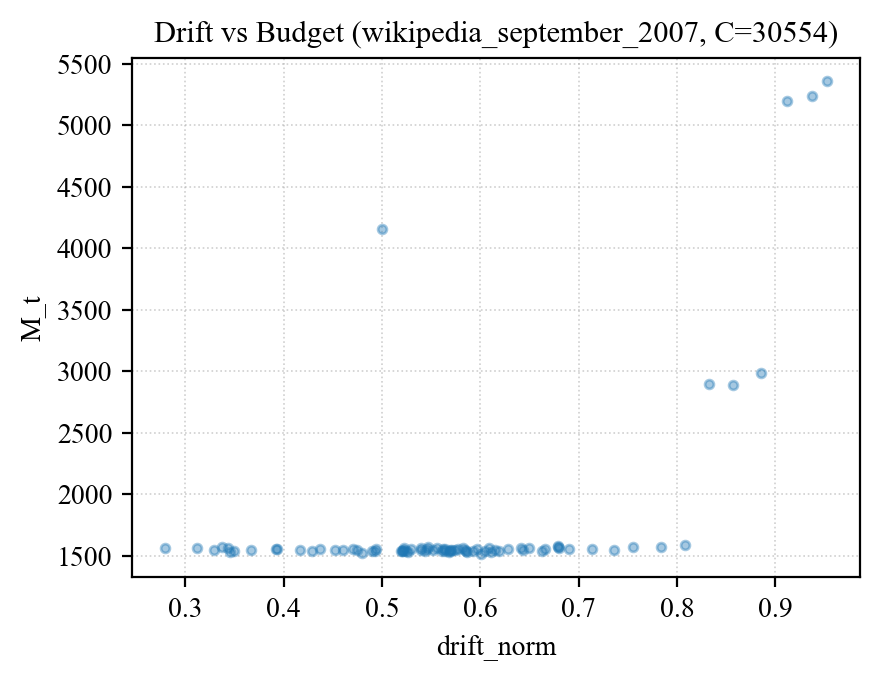

In [7]:
for dataset in DATASETS:
    dataset_dir = RESULTS_ROOT / dataset
    records = load_latest_summaries(dataset_dir)
    cache_ts = CACHE_FOR_TIMESERIES[dataset]
    s = records.get(('ilnse_A2_full', cache_ts))
    slot_path = Path(s['slot_log_path'])

    drift, budget = [], []
    for row in iter_jsonl(slot_path):
        if row.get('phase') != 'cache':
            continue
        drift.append(row.get('drift_norm', 0.0))
        budget.append(row.get('admit_budget', 0))

    fig, ax = plt.subplots(figsize=(4.5, 3.5), dpi=200)
    ax.scatter(drift, budget, s=10, alpha=0.4, color='#1f77b4')
    ax.set_xlabel('drift_norm')
    ax.set_ylabel('M_t')
    ax.set_title(f'Drift vs Budget ({dataset}, C={cache_ts})')
    ax.set_axisbelow(True)

    out = OUT_DIR / f'fig_A2c_drift_scatter_{dataset}_{cache_ts}.pdf'
    save_fig(fig, out)



## Fig. A3 — Binned Drift vs Mean Budget (all datasets)

**Tujuan:** menampilkan hubungan drift→budget secara agregat (tanpa statistik rumit).
**Data:** slot‑log JSONL; drift_norm dibagi low/mid/high.
**Output:** bar chart mean M_t per bin drift.



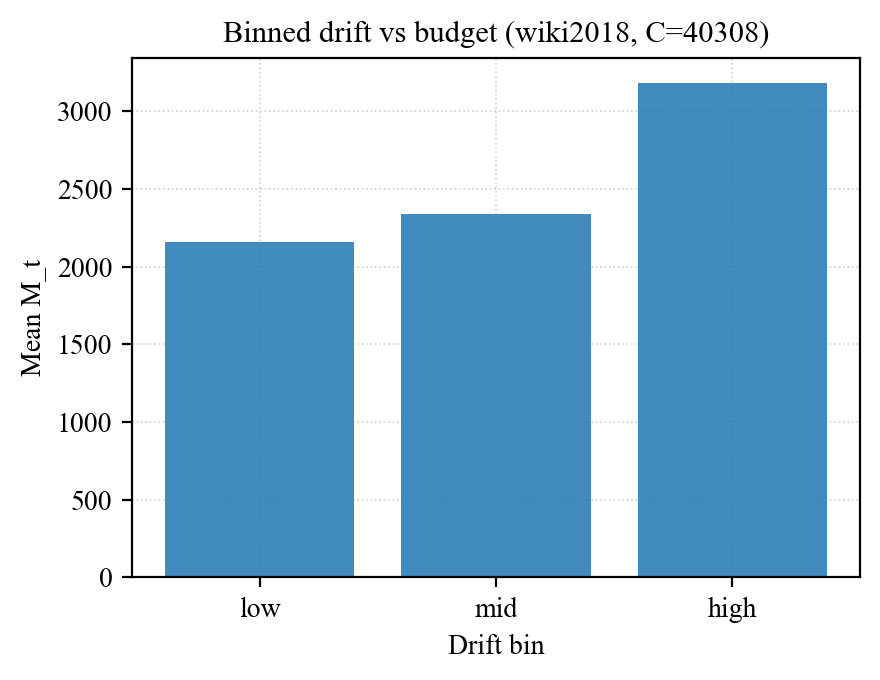

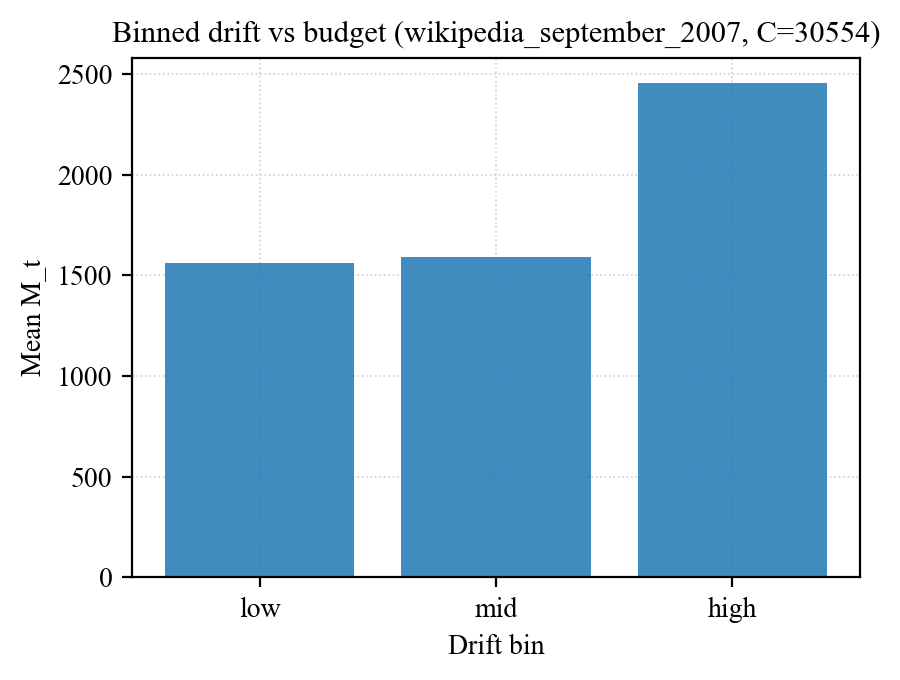

In [8]:
bins = [0.0, 0.33, 0.66, 1.0]
labels = ['low','mid','high']

for dataset in DATASETS:
    dataset_dir = RESULTS_ROOT / dataset
    records = load_latest_summaries(dataset_dir)
    cache_ts = CACHE_FOR_TIMESERIES[dataset]
    s = records.get(('ilnse_A2_full', cache_ts))
    slot_path = Path(s['slot_log_path'])

    groups = {k: [] for k in labels}
    for row in iter_jsonl(slot_path):
        if row.get('phase') != 'cache':
            continue
        d = row.get('drift_norm', 0.0)
        m = row.get('admit_budget', 0)
        if d < bins[1]:
            groups['low'].append(m)
        elif d < bins[2]:
            groups['mid'].append(m)
        else:
            groups['high'].append(m)

    means = [statistics.mean(groups[k]) if groups[k] else 0.0 for k in labels]
    fig, ax = plt.subplots(figsize=(4.5, 3.5), dpi=200)
    ax.bar(labels, means, color='#1f77b4', alpha=0.85)
    ax.set_ylabel('Mean M_t')
    ax.set_xlabel('Drift bin')
    ax.set_title(f'Binned drift vs budget ({dataset}, C={cache_ts})')
    ax.set_axisbelow(True)

    out = OUT_DIR / f'fig_A3_binned_budget_{dataset}_{cache_ts}.pdf'
    save_fig(fig, out)



## Fig. B1 — Churn/Evictions vs Cache Size (all datasets)

**Tujuan:** bukti kontribusi 2 — guardrails menahan churn/evictions.
**Data:** summary JSON (`cache_evictions_avg`).
**Output:** kurva evictions vs C untuk Drift‑only vs Full.



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


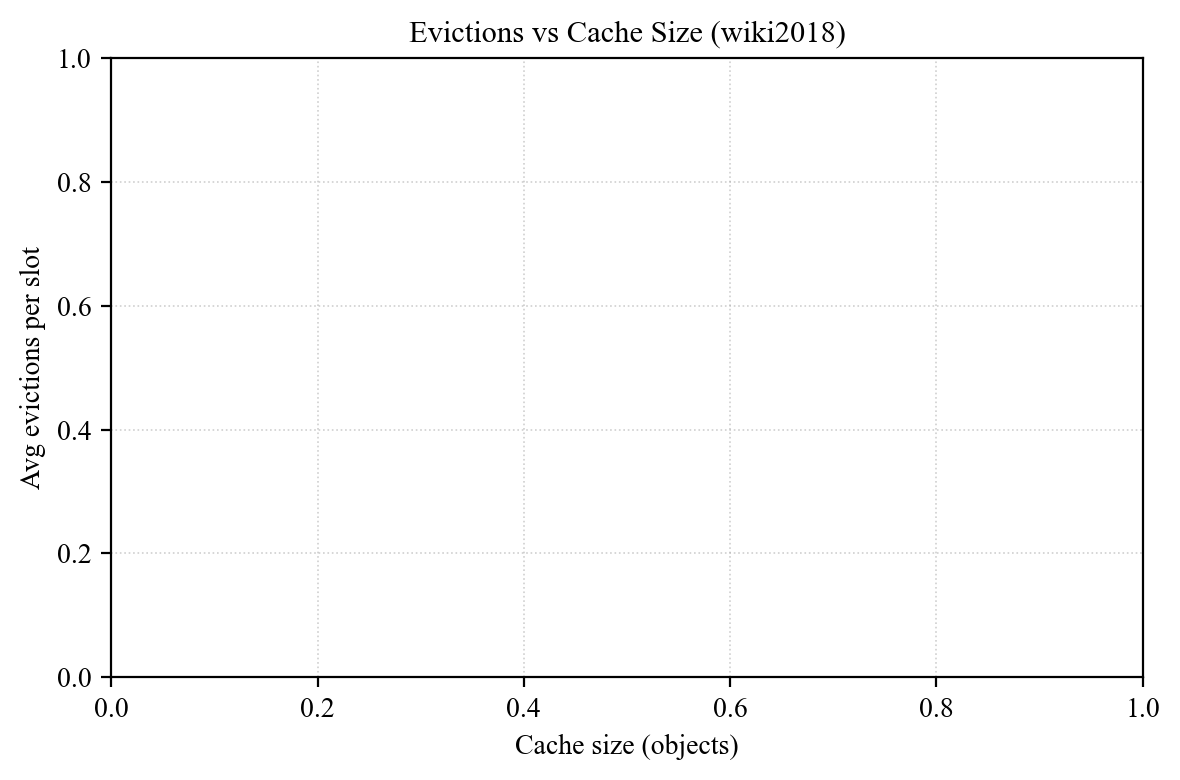

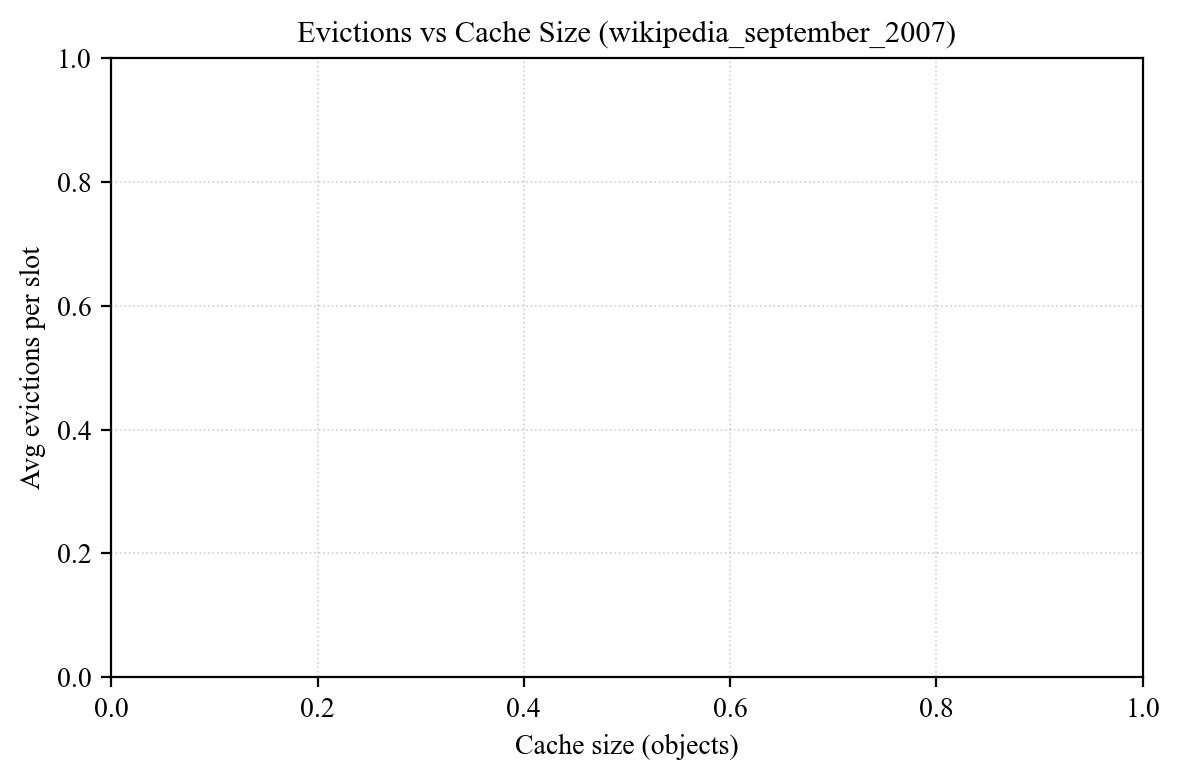

In [9]:
for dataset in DATASETS:
    dataset_dir = RESULTS_ROOT / dataset
    records = load_latest_summaries(dataset_dir)
    caches = get_caches(records)
    fig, ax = plt.subplots(figsize=(6.0, 4.0), dpi=200)
    for m in ['ilnse_A2_drift_only','ilnse_A2_full']:
        pts = []
        for c in caches:
            val = records.get((m,c), {}).get('cache_evictions_avg')
            if val is None:
                continue
            pts.append((c, val))
        if not pts:
            continue
        pts.sort(key=lambda x: x[0])
        xs = [p[0] for p in pts]; ys = [p[1] for p in pts]
        ax.plot(xs, ys, label=M_A1_LABELS.get(m, m), **STYLE.get(m, {}))
    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('Avg evictions per slot')
    ax.set_title(f'Evictions vs Cache Size ({dataset})')
    ax.legend(frameon=False, loc='upper right')
    ax.set_axisbelow(True)

    out = OUT_DIR / f'fig_B1_evictions_{dataset}.pdf'
    save_fig(fig, out)



## Fig. B2 — Lag‑Precision vs Budget (slot‑level, all datasets)

**Tujuan:** menunjukkan guardrail berbasis delayed utility bekerja.
**Data:** slot‑log JSONL (`admission_precision_eff`, `admit_budget`).
**Output:** time‑series Prec_eff (kiri) dan M_t (kanan) pada slot yang sama.



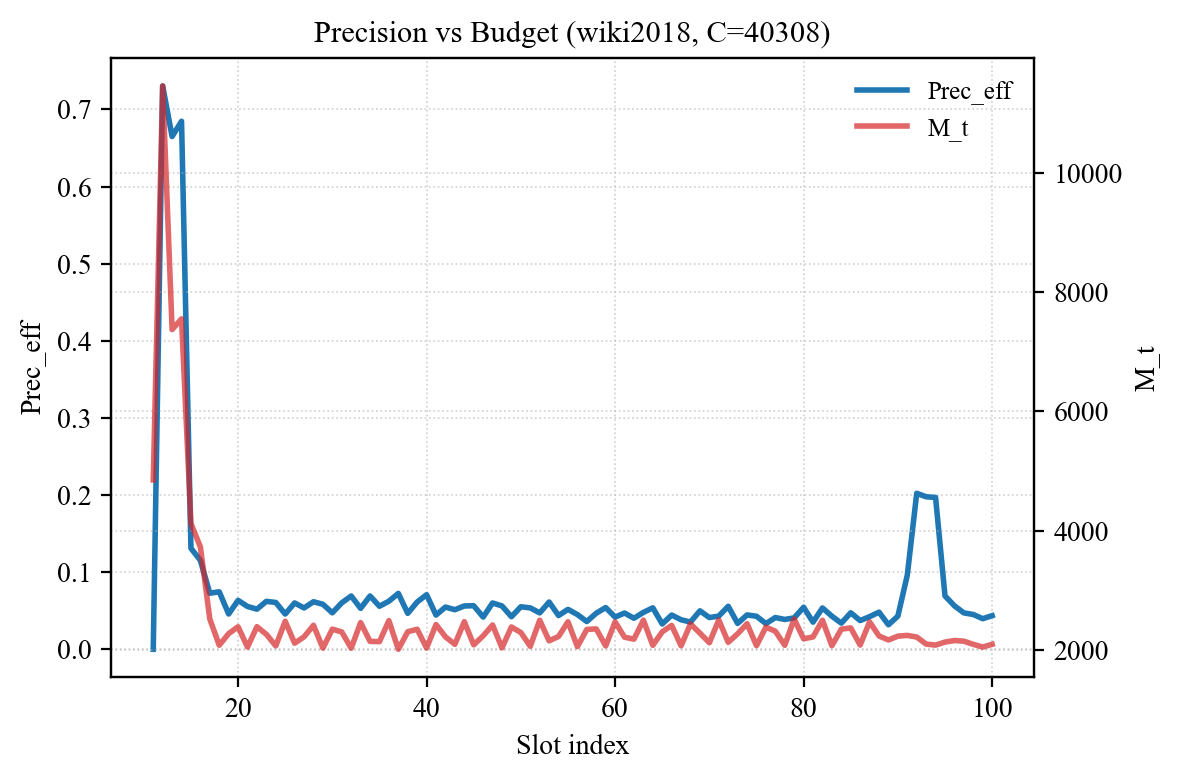

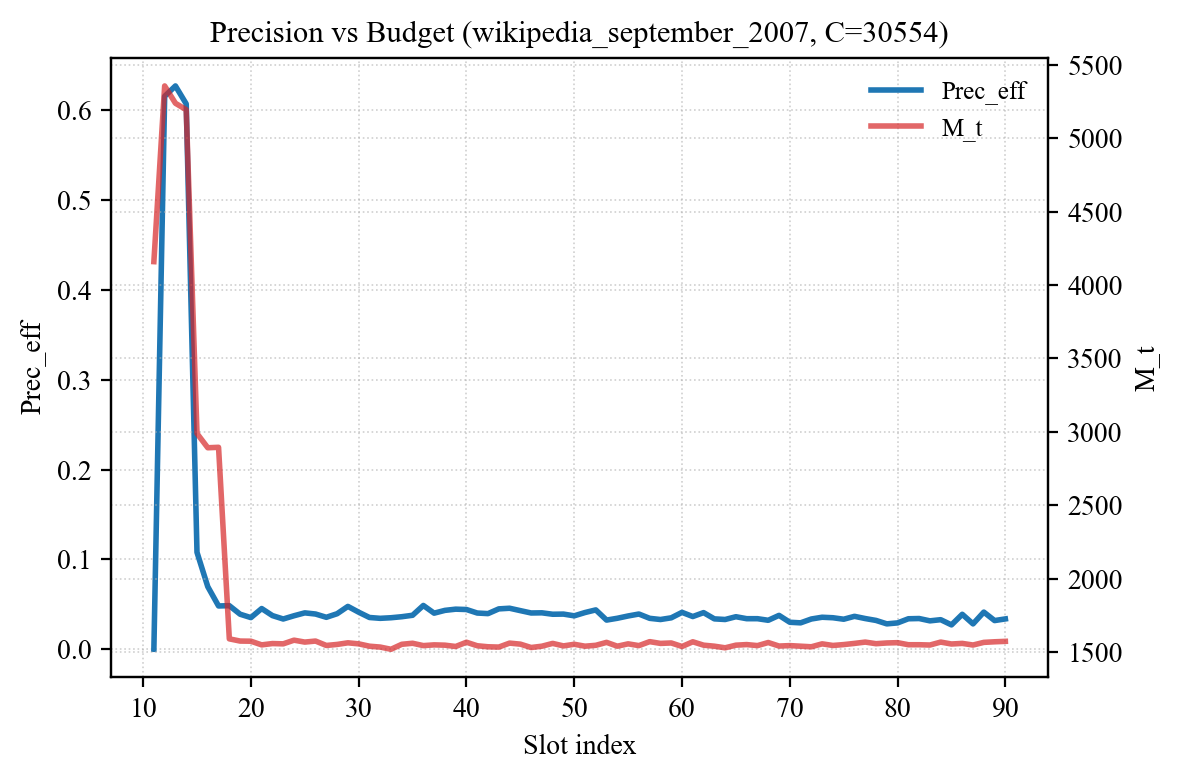

In [10]:
for dataset in DATASETS:
    dataset_dir = RESULTS_ROOT / dataset
    records = load_latest_summaries(dataset_dir)
    cache_ts = CACHE_FOR_TIMESERIES[dataset]
    s = records.get(('ilnse_A2_full', cache_ts))
    slot_path = Path(s['slot_log_path'])

    prec, budget, slots = [], [], []
    for row in iter_jsonl(slot_path):
        if row.get('phase') != 'cache':
            continue
        slots.append(row.get('slot_index'))
        pe = row.get('admission_precision_eff')
        if pe is None:
            lags = [row.get('admission_precision_lag0'), row.get('admission_precision_lag1'), row.get('admission_precision_lag2')]
            lags = [v for v in lags if v is not None]
            pe = (sum(lags) / len(lags)) if lags else 0.0
        prec.append(pe)
        budget.append(row.get('admit_budget') or 0)

    fig, ax = plt.subplots(figsize=(6.0, 4.0), dpi=200)
    ax.plot(slots, prec, color='#1f77b4', label='Prec_eff')
    ax2 = ax.twinx()
    ax2.plot(slots, budget, color='#d62728', alpha=0.7, label='M_t')
    ax.set_xlabel('Slot index')
    ax.set_ylabel('Prec_eff')
    ax2.set_ylabel('M_t')
    ax.set_title(f'Precision vs Budget ({dataset}, C={cache_ts})')
    ax.set_axisbelow(True)
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, frameon=False, loc='upper right')

    out = OUT_DIR / f'fig_B2_precision_budget_{dataset}_{cache_ts}.pdf'
    save_fig(fig, out)



## Fig. B3 — Score Quality vs Admission (scatter, stratified)

**Tujuan:** memperjelas efek score‑quality gating tanpa bias fill‑phase.
**Data:** slot‑log JSONL (`quality_mult`, `admit_selected`, `drift_norm`, `fill_phase`).
**Output:** scatter quality_mult vs |A_t|, **hanya non‑fill slots**, warna menunjukkan drift bin.



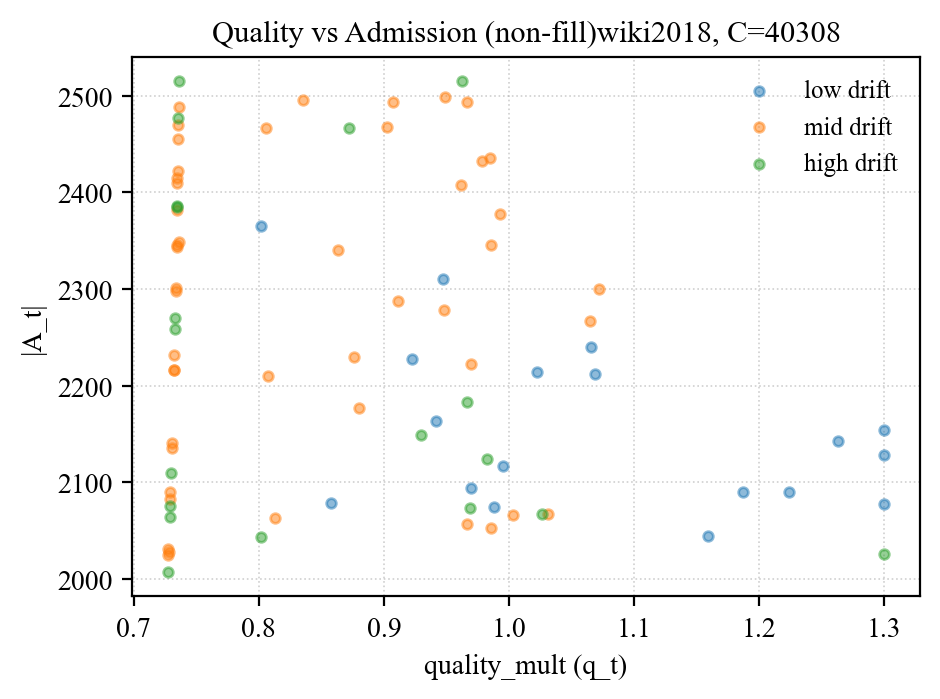

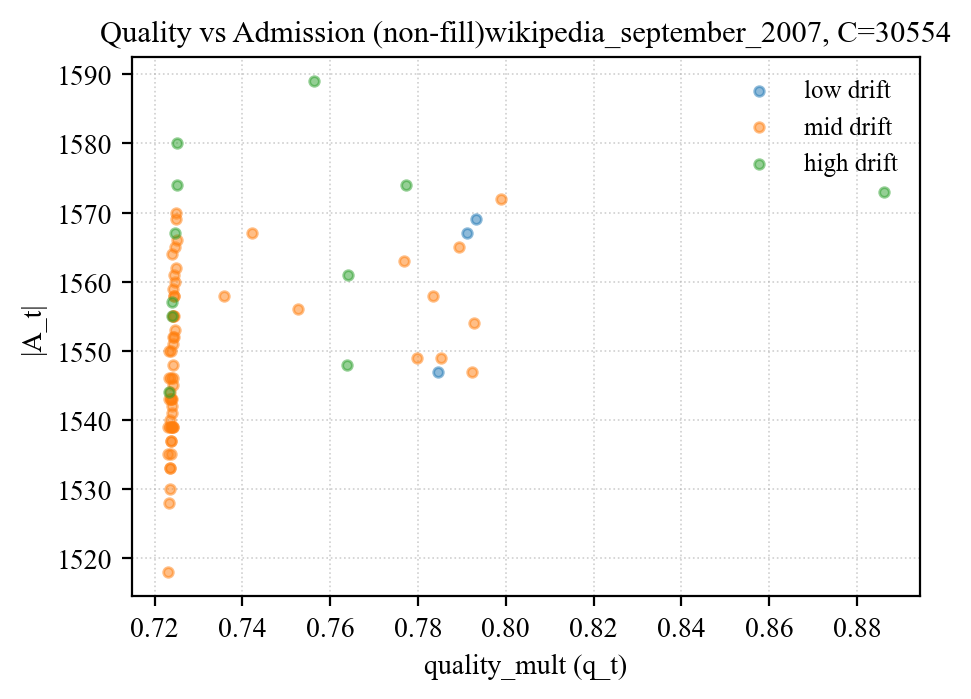

In [11]:
bins = [0.0, 0.33, 0.66, 1.0]
colors = {'low':'#1f77b4','mid':'#ff7f0e','high':'#2ca02c'}

for dataset in DATASETS:
    dataset_dir = RESULTS_ROOT / dataset
    records = load_latest_summaries(dataset_dir)
    cache_ts = CACHE_FOR_TIMESERIES[dataset]
    s = records.get(('ilnse_A2_full', cache_ts))
    slot_path = Path(s['slot_log_path'])

    buckets = {'low': ([], []), 'mid': ([], []), 'high': ([], [])}
    for row in iter_jsonl(slot_path):
        if row.get('phase') != 'cache':
            continue
        if row.get('fill_phase'):
            continue  # remove fill-phase confounder
        qv = row.get('quality_mult', row.get('quality_mult_ema'))
        if qv is None:
            continue
        d = row.get('drift_norm', 0.0)
        if d < bins[1]:
            key = 'low'
        elif d < bins[2]:
            key = 'mid'
        else:
            key = 'high'
        buckets[key][0].append(qv)
        buckets[key][1].append(row.get('admit_selected', 0))

    fig, ax = plt.subplots(figsize=(4.8, 3.6), dpi=200)
    for k,(qx,ay) in buckets.items():
        if not qx:
            continue
        ax.scatter(qx, ay, s=12, alpha=0.5, color=colors[k], label=f'{k} drift')
    ax.set_xlabel('quality_mult (q_t)')
    ax.set_ylabel('|A_t|')
    ax.set_title(f'Quality vs Admission (non-fill){dataset}, C={cache_ts}')
    ax.legend(frameon=False)
    ax.set_axisbelow(True)

    out = OUT_DIR / f'fig_B3_quality_scatter_{dataset}_{cache_ts}.pdf'
    save_fig(fig, out)



## Fig. B3c — Quality → Budget Ratio (final / pre‑gate)

**Tujuan:** mengisolasi efek gating dengan melihat **rasio budget final terhadap pre‑gate**.
**Data:** slot‑log JSONL (`quality_mult`, `admit_budget`, `admission_alpha`, `pressure_mult`, `miss_candidates`).
**Output:** scatter quality_mult vs (M_t / M_pre). Rasio < 1 menunjukkan pengetatan oleh gate.



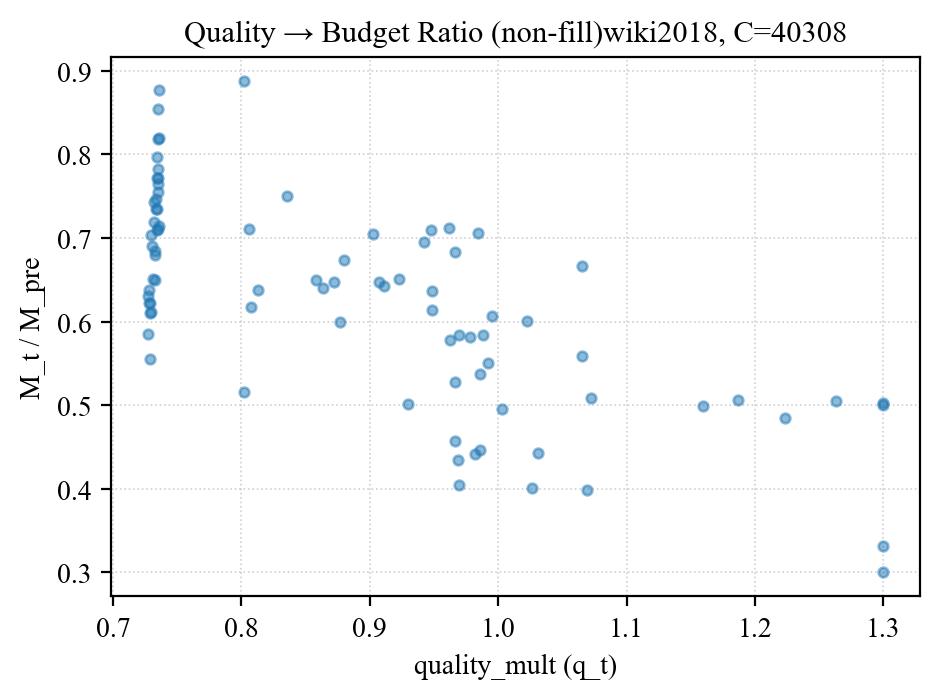

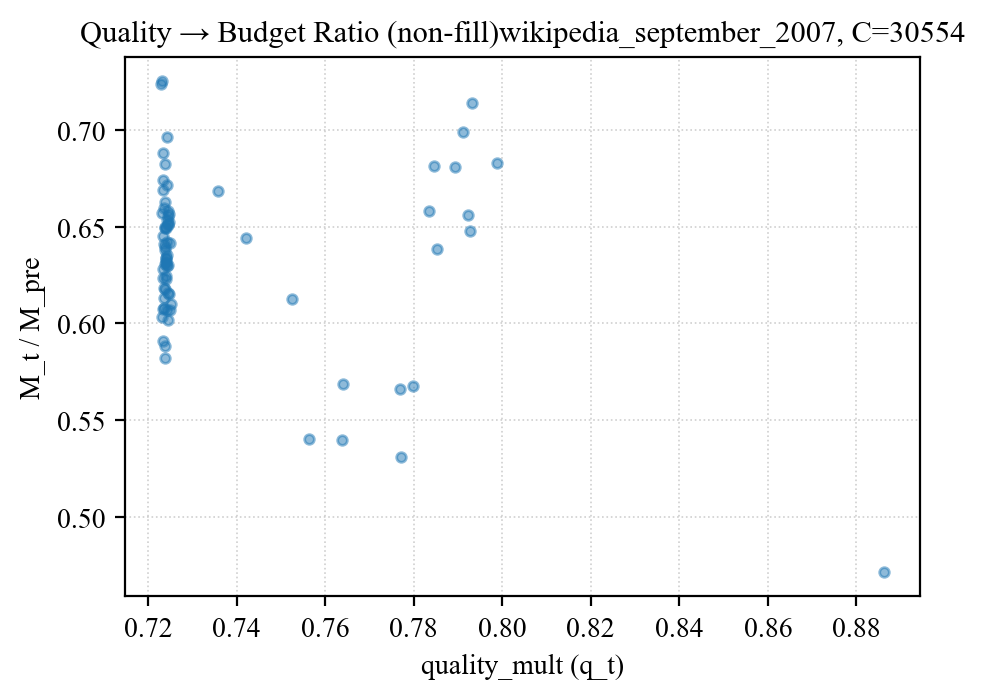

In [13]:
for dataset in DATASETS:
    dataset_dir = RESULTS_ROOT / dataset
    records = load_latest_summaries(dataset_dir)
    cache_ts = CACHE_FOR_TIMESERIES[dataset]
    s = records.get(('ilnse_A2_full', cache_ts))
    slot_path = Path(s['slot_log_path'])
    capacity_objects = records.get(('ilnse_A2_full', cache_ts), {}).get('cache_size_objects', cache_ts)

    q, ratio = [], []
    for row in iter_jsonl(slot_path):
        if row.get('phase') != 'cache':
            continue
        if row.get('fill_phase'):
            continue
        qv = row.get('quality_mult', row.get('quality_mult_ema'))
        if qv is None:
            continue
        pre = compute_pre_gate_budget(row, capacity_objects)
        final = row.get('admit_budget', 0)
        if pre <= 0:
            continue
        q.append(qv)
        ratio.append(final / pre)

    fig, ax = plt.subplots(figsize=(4.8, 3.6), dpi=200)
    ax.scatter(q, ratio, s=12, alpha=0.5, color='#1f77b4')
    ax.set_xlabel('quality_mult (q_t)')
    ax.set_ylabel('M_t / M_pre')
    ax.set_title(f'Quality → Budget Ratio (non-fill){dataset}, C={cache_ts}')
    ax.set_axisbelow(True)

    out = OUT_DIR / f'fig_B3c_quality_ratio_{dataset}_{cache_ts}.pdf'
    save_fig(fig, out)

## Fig. B3b — Score Quality vs Budget (time‑series)

**Tujuan:** menunjukkan gating score‑quality aktif mengubah budget secara temporal.
**Data:** slot‑log JSONL (`quality_mult`, `admit_budget`).
**Output:** time‑series quality_mult dan M_t.



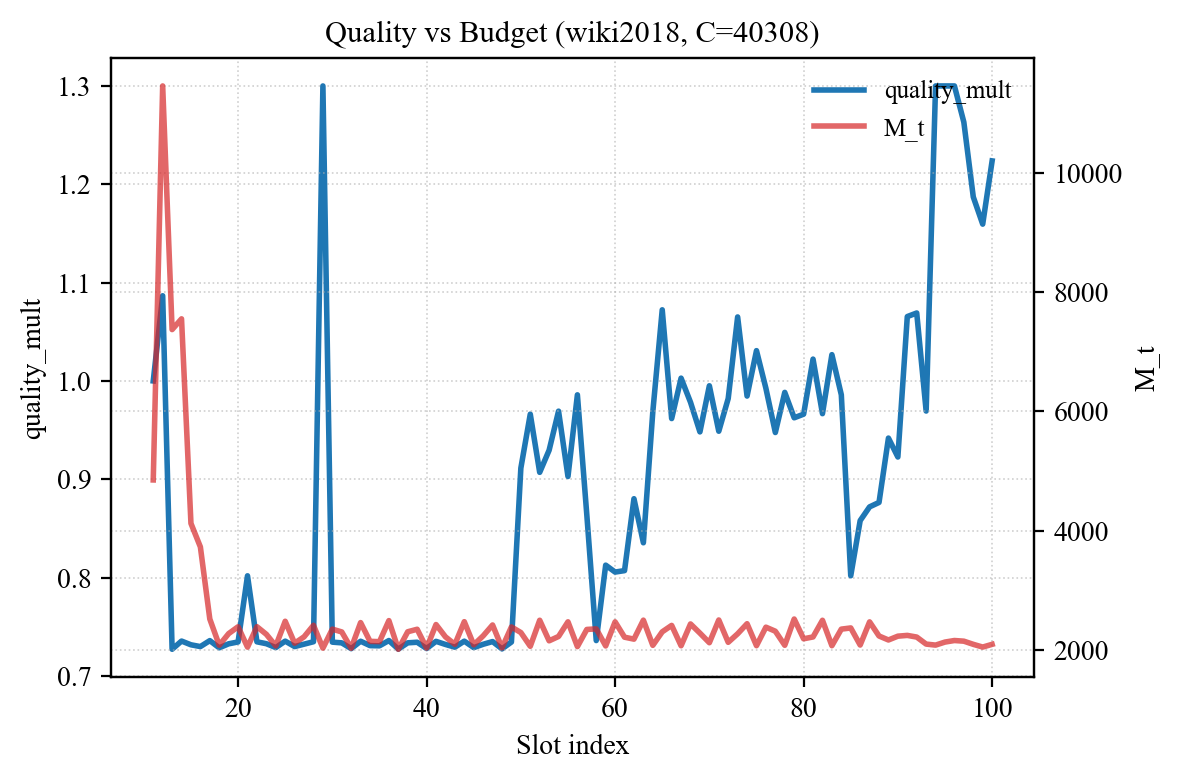

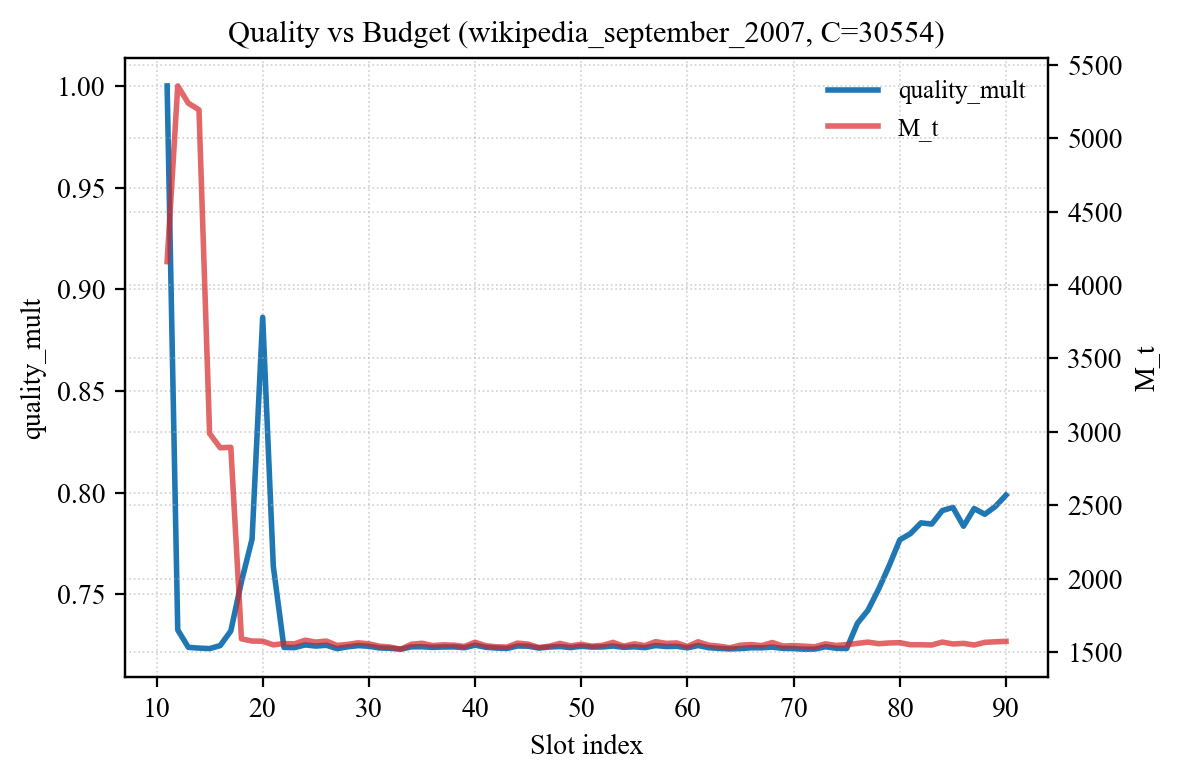

In [14]:
for dataset in DATASETS:
    dataset_dir = RESULTS_ROOT / dataset
    records = load_latest_summaries(dataset_dir)
    cache_ts = CACHE_FOR_TIMESERIES[dataset]
    s = records.get(('ilnse_A2_full', cache_ts))
    slot_path = Path(s['slot_log_path'])

    q, budget, slots = [], [], []
    for row in iter_jsonl(slot_path):
        if row.get('phase') != 'cache':
            continue
        slots.append(row.get('slot_index'))
        qv = row.get('quality_mult', row.get('quality_mult_ema'))
        if qv is None:
            qv = 1.0
        q.append(qv)
        budget.append(row.get('admit_budget', 0))

    fig, ax = plt.subplots(figsize=(6.0, 4.0), dpi=200)
    ax.plot(slots, q, color='#1f77b4', label='quality_mult')
    ax2 = ax.twinx()
    ax2.plot(slots, budget, color='#d62728', alpha=0.7, label='M_t')
    ax.set_xlabel('Slot index')
    ax.set_ylabel('quality_mult')
    ax2.set_ylabel('M_t')
    ax.set_title(f'Quality vs Budget ({dataset}, C={cache_ts})')
    ax.set_axisbelow(True)
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, frameon=False, loc='upper right')

    out = OUT_DIR / f'fig_B3b_quality_budget_{dataset}_{cache_ts}.pdf'
    save_fig(fig, out)



## Fig. C1 — Ablation Summary (HR & Churn, all datasets)

**Tujuan:** memisahkan efek drift‑only vs guardrails‑only vs full.
**Data:** summary JSON (mean HR dan mean evictions).
**Output:** bar chart HR dan churn untuk varian ablation.



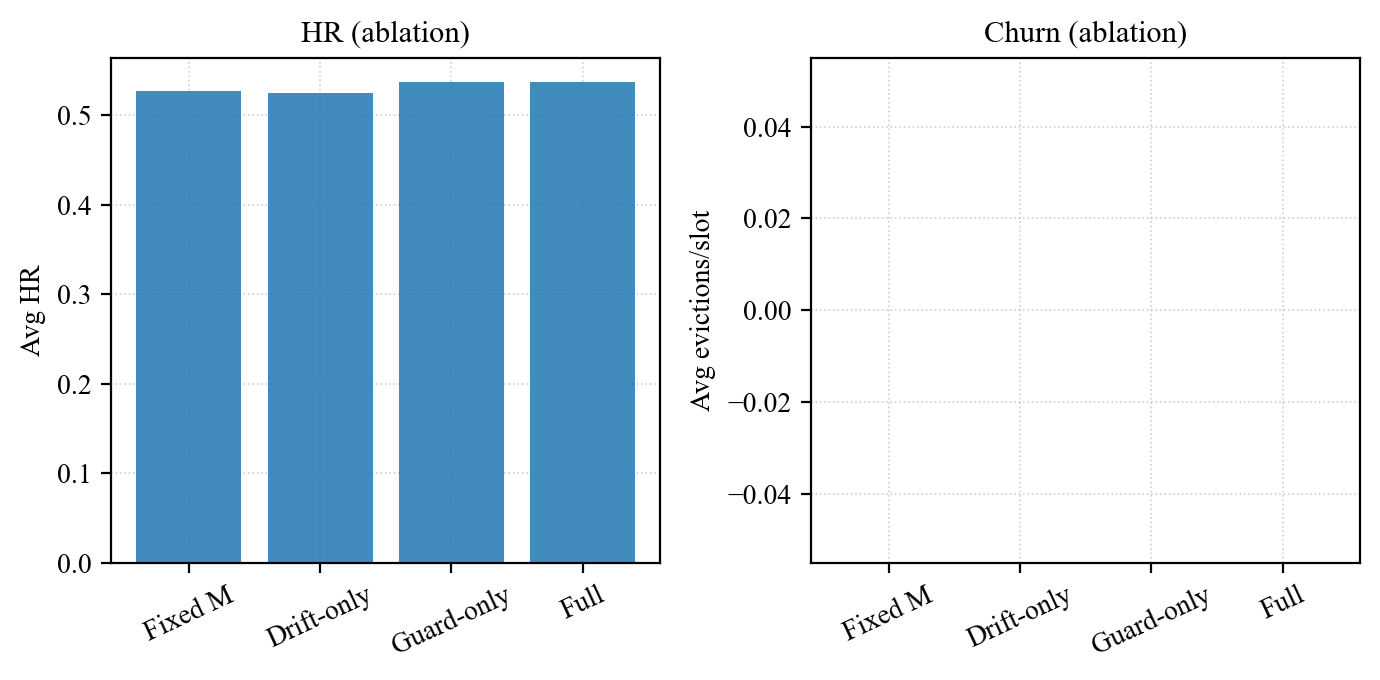

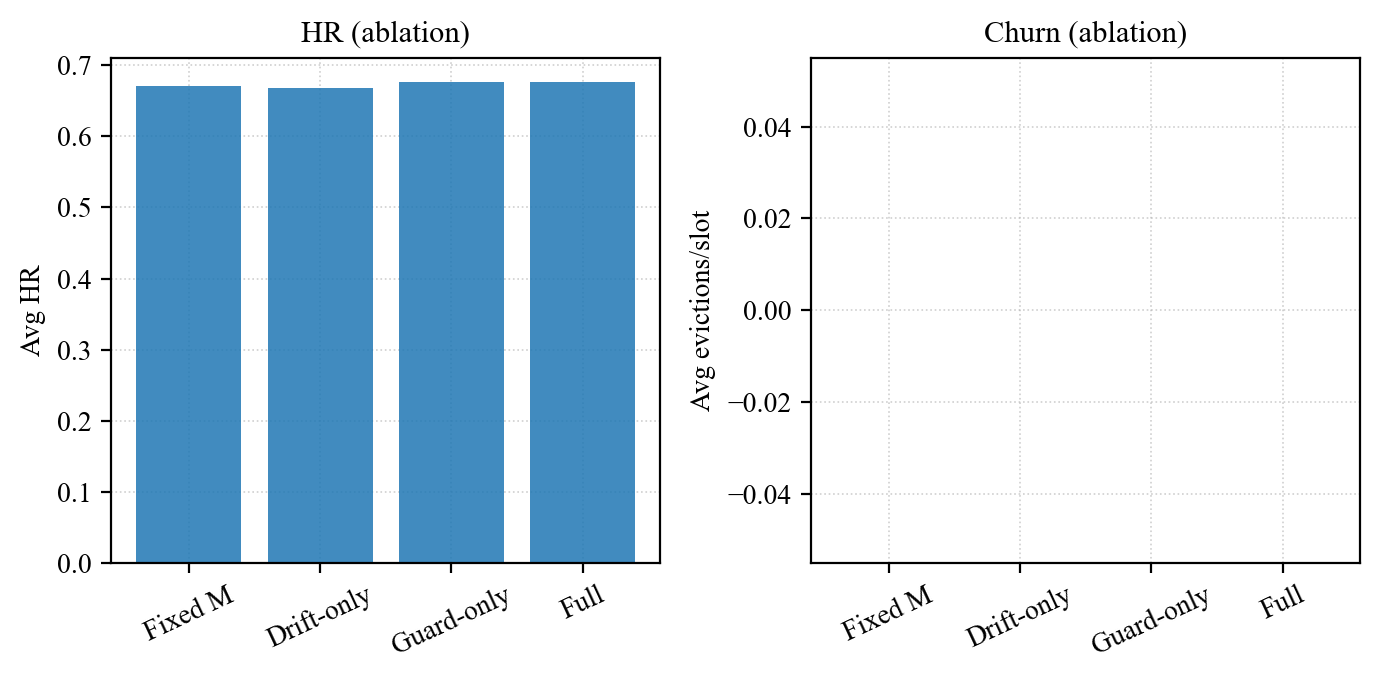

In [15]:
for dataset in DATASETS:
    dataset_dir = RESULTS_ROOT / dataset
    records = load_latest_summaries(dataset_dir)
    caches = get_caches(records)
    labels = []
    hr_vals = []
    evict_vals = []
    label_map = {
        'ilnse_A2_fixed': 'Fixed M',
        'ilnse_A2_drift_only': 'Drift-only',
        'ilnse_A2_guard_only': 'Guard-only',
        'ilnse_A2_full': 'Full',
    }

    for m in M_ABL:
        hrs = []
        evs = []
        for c in caches:
            s = records.get((m,c), {})
            if s.get('hit_ratio') is not None:
                hrs.append(s.get('hit_ratio'))
            if s.get('cache_evictions_avg') is not None:
                evs.append(s.get('cache_evictions_avg'))
        if not hrs:
            continue
        labels.append(label_map.get(m, m))
        hr_vals.append(statistics.mean(hrs))
        evict_vals.append(statistics.mean(evs) if evs else 0.0)

    fig, axs = plt.subplots(1, 2, figsize=(7.0, 3.5), dpi=200)
    axs[0].bar(labels, hr_vals, color='#1f77b4', alpha=0.85)
    axs[0].set_ylabel('Avg HR')
    axs[0].set_title('HR (ablation)')
    axs[0].tick_params(axis='x', rotation=25)

    axs[1].bar(labels, evict_vals, color='#ff7f0e', alpha=0.85)
    axs[1].set_ylabel('Avg evictions/slot')
    axs[1].set_title('Churn (ablation)')
    axs[1].tick_params(axis='x', rotation=25)

    for ax in axs:
        ax.set_axisbelow(True)

    out = OUT_DIR / f'fig_C1_ablation_{dataset}.pdf'
    save_fig(fig, out)